In [4]:
from typing import Dict, Hashable, Iterable, Tuple, Any, Optional
from sklearn.metrics import adjusted_mutual_info_score, normalized_mutual_info_score


Node = Hashable
Time = Hashable
Key = Tuple[Node, Time]


def dynamic_mi(
    gt: Dict[Key, Any],
    pred: Dict[Key, Any],
    keys: Optional[Iterable[Key]] = None,
    average_method: str = "arithmetic",
    normalisation: str = "ami" or "nmi"
) -> float:
    if keys is None:
        keys = set(gt.keys()) | set(pred.keys())

    keys = list(keys)

    y_true = []
    y_pred = []
    for k in keys:
        if k not in gt or k not in pred:
            raise KeyError(f"node {k} is missing in either gt or pred")
        y_true.append(gt[k])
        y_pred.append(pred[k])

    if len(y_true) == 0:
        raise ValueError("no samples left after filtering missing nodes")

    if normalisation == "ami":
        return float(adjusted_mutual_info_score(y_true, y_pred, average_method=average_method))
    elif normalisation == "nmi":
        return float(normalized_mutual_info_score(y_true, y_pred, average_method=average_method)) 
    else:
        return ("AttributeError")

In [7]:
from __future__ import annotations

from typing import Dict, Hashable, Tuple, Any, Optional, Literal
import pandas as pd

Node = Hashable
Time = Hashable
Key = Tuple[Node, Time]


def build_partition_from_csv(
    csv_path: str,
    *,
    source_col: str = "source",
    destination_col: str = "destination",
    timestamp_col: str = "timestamp",
    source_commu_col: str = "source_commu",
    destination_commu_col: str = "destination_commu",
    sep: str = ",",
    header: Optional[int] = "infer",
    skip_first_row: bool = False,
    dtype_source: Any = int,
    dtype_destination: Any = int,
    dtype_timestamp: Any = int,
    dtype_commu: Any = int,
    on_conflict: Literal["keep_first", "keep_last", "error"] = "keep_last",
) -> Dict[Key, Any]:
    usecols = [source_col, destination_col, timestamp_col, source_commu_col, destination_commu_col]

    df = pd.read_csv(
        csv_path,
        sep=sep,
        header=header,
        usecols=usecols,
        skiprows=1 if skip_first_row else None,
    )

    df[source_col] = df[source_col].astype(dtype_source)
    df[destination_col] = df[destination_col].astype(dtype_destination)
    df[timestamp_col] = df[timestamp_col].astype(dtype_timestamp)
    df[source_commu_col] = df[source_commu_col].astype(dtype_commu)
    df[destination_commu_col] = df[destination_commu_col].astype(dtype_commu)

    part: Dict[Key, Any] = {}

    def _assign(k: Key, v: Any):
        if k not in part:
            part[k] = v
            return
        if part[k] == v:
            return
        if on_conflict == "keep_first":
            return
        if on_conflict == "keep_last":
            part[k] = v
            return
        raise ValueError(f"Conflict on {k}: existing={part[k]} new={v}")

    for s, d, t, cs, cd in df[[source_col, destination_col, timestamp_col, source_commu_col, destination_commu_col]].itertuples(index=False, name=None):
        _assign((s, t), cs)
        _assign((d, t), cd)

    return part


gt = build_partition_from_csv("syn_data/syn_net_p0.8_mu0.2_1.csv")
pred = build_partition_from_csv("result/TGN_community.csv")

In [8]:
dynamic_ami_score = dynamic_mi(gt, pred, normalisation="ami")
print("Dynamic AMI =", dynamic_ami_score)

Dynamic AMI = 0.014448153926349863


In [8]:
gt = build_partition_from_csv("syn_data/syn_net_p0.8_mu0.2.csv")
lago_pred = build_partition_from_csv("results/lago/syn_net_p0.8_mu0.2.csv")
lago_score = dynamic_mi(gt, lago_pred, normalisation="ami")
print("LAGO Dynamic AMI =", lago_score)

LAGO Dynamic AMI = 0.38111463885559094


In [44]:
from __future__ import annotations

from pathlib import Path
import re
import pandas as pd


def compare_dynamic_ami_by_filename_parse_pm(
    syn_folder: str | Path,
    res_folder: str | Path,
    *,
    normalisation: str = "ami",
    pattern: str = "*.csv",
    save_csv: bool = True,
    out_name: str = "dynamic_ami_summary.csv",
    filename_regex: str = r"_p(?P<p>-?\d+(?:\.\d+)?)_mu(?P<mu>-?\d+(?:\.\d+)?)",
    skip_unparseable: bool = True,
) -> pd.DataFrame:
    """
    Match files by same filename in syn_folder and res_folder, compute dynamic_mi score,
    but store parsed (p, mu) instead of filename.

    Filenames expected like: syn_net_p1.0_mu0.05.csv
    """
    syn_folder = Path(syn_folder)
    res_folder = Path(res_folder)

    if not syn_folder.exists() or not syn_folder.is_dir():
        raise FileNotFoundError(f"syn_folder not found or not a directory: {syn_folder}")
    if not res_folder.exists() or not res_folder.is_dir():
        raise FileNotFoundError(f"res_folder not found or not a directory: {res_folder}")

    syn_files = {p.name: p for p in syn_folder.glob(pattern) if p.is_file()}
    res_files = {p.name: p for p in res_folder.glob(pattern) if p.is_file()}

    common = sorted(set(syn_files.keys()) & set(res_files.keys()))
    if not common:
        raise FileNotFoundError(
            f"No matching filenames between {syn_folder} and {res_folder} for pattern '{pattern}'."
        )

    pat = re.compile(filename_regex, re.IGNORECASE)

    def _parse_pm(name: str):
        m = pat.search(name)
        if not m:
            return None, None
        try:
            return float(m.group("p")), float(m.group("mu"))
        except Exception:
            return None, None

    rows = []

    # --- common files: compute score ---
    for name in common:
        p_val, mu_val = _parse_pm(name)
        if (p_val is None or mu_val is None) and skip_unparseable:
            print(f"[WARN] cannot parse p/mu from filename, skipped: {name}")
            continue

        gt_path = syn_files[name]
        pred_path = res_files[name]

        try:
            gt = build_partition_from_csv(str(gt_path))
            pred = build_partition_from_csv(str(pred_path))
            score = dynamic_mi(gt, pred, normalisation=normalisation)

            rows.append({
                "p": p_val,
                "mu": mu_val,
                "gt_path": str(gt_path),
                "pred_path": str(pred_path),
                "normalisation": normalisation,
                "score": float(score),
                "status": "ok",
            })
        except Exception as e:
            rows.append({
                "p": p_val,
                "mu": mu_val,
                "gt_path": str(gt_path),
                "pred_path": str(pred_path),
                "normalisation": normalisation,
                "score": None,
                "status": f"error: {type(e).__name__}: {e}",
            })

    # --- missing predictions ---
    missing_in_res = sorted(set(syn_files.keys()) - set(res_files.keys()))
    for name in missing_in_res:
        p_val, mu_val = _parse_pm(name)
        if (p_val is None or mu_val is None) and skip_unparseable:
            print(f"[WARN] cannot parse p/mu from filename (missing_pred row skipped): {name}")
            continue
        rows.append({
            "p": p_val,
            "mu": mu_val,
            "gt_path": str(syn_files[name]),
            "pred_path": None,
            "normalisation": normalisation,
            "score": None,
            "status": "missing_pred",
        })

    # --- missing GTs ---
    missing_in_syn = sorted(set(res_files.keys()) - set(syn_files.keys()))
    for name in missing_in_syn:
        p_val, mu_val = _parse_pm(name)
        if (p_val is None or mu_val is None) and skip_unparseable:
            print(f"[WARN] cannot parse p/mu from filename (missing_gt row skipped): {name}")
            continue
        rows.append({
            "p": p_val,
            "mu": mu_val,
            "gt_path": None,
            "pred_path": str(res_files[name]),
            "normalisation": normalisation,
            "score": None,
            "status": "missing_gt",
        })

    df = pd.DataFrame(rows)

    if save_csv:
        out_path = res_folder / out_name
        df.to_csv(out_path, index=False)

    return df

df = compare_dynamic_ami_by_filename_parse_pm(
    syn_folder="syn_data",
    res_folder="results/lago",
    normalisation="ami",
)
(df.sort_values("score", ascending=False).head(10))

,p,mu,gt_path,pred_path,normalisation,score,status
21,1.00,0.05,syn_data/syn_net_p1.0_mu0.05.csv,results/lago/syn_net_p1.0_mu0.05.csv,ami,1.000000,ok
20,1.00,0.00,syn_data/syn_net_p1.0_mu0.0.csv,results/lago/syn_net_p1.0_mu0.0.csv,ami,1.000000,ok
10,0.95,0.00,syn_data/syn_net_p0.95_mu0.0.csv,results/lago/syn_net_p0.95_mu0.0.csv,ami,0.963003,ok
12,0.95,0.10,syn_data/syn_net_p0.95_mu0.1.csv,results/lago/syn_net_p0.95_mu0.1.csv,ami,0.925894,ok
22,1.00,0.10,syn_data/syn_net_p1.0_mu0.1.csv,results/lago/syn_net_p1.0_mu0.1.csv,ami,0.919958,ok
17,0.90,0.10,syn_data/syn_net_p0.9_mu0.1.csv,results/lago/syn_net_p0.9_mu0.1.csv,ami,0.856280,ok
15,0.90,0.00,syn_data/syn_net_p0.9_mu0.0.csv,results/lago/syn_net_p0.9_mu0.0.csv,ami,0.837522,ok
11,0.95,0.05,syn_data/syn_net_p0.95_mu0.05.csv,results/lago/syn_net_p0.95_mu0.05.csv,ami,0.832600,ok
2,0.85,0.10,syn_data/syn_net_p0.85_mu0.1.csv,results/lago/syn_net_p0.85_mu0.1.csv,ami,0.829894,ok
16,0.90,0.05,syn_data/syn_net_p0.9_mu0.05.csv,results/lago/syn_net_p0.9_mu0.05.csv,ami,0.805819,ok


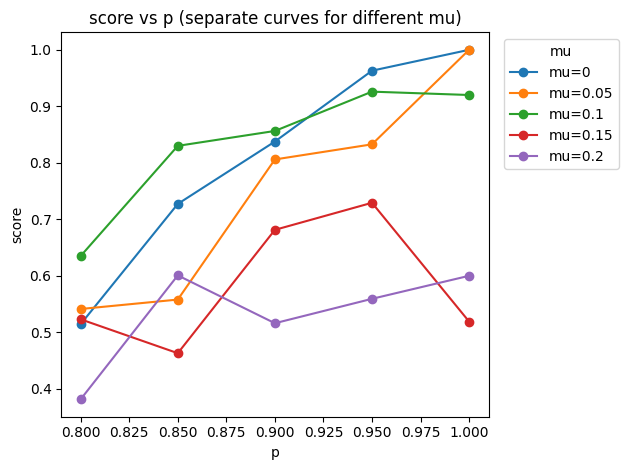

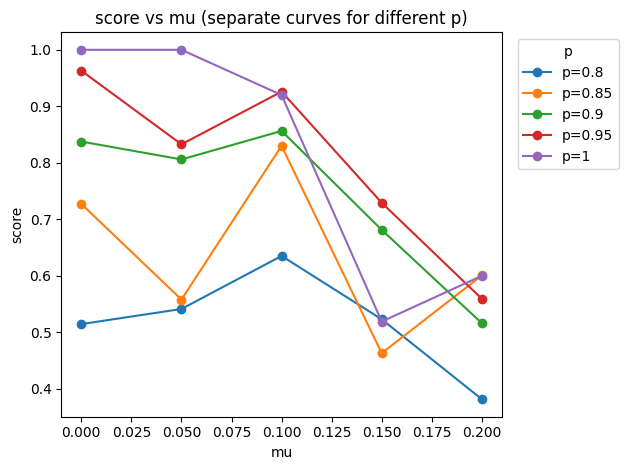

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# df 需要包含：p, mu, score
required = {"p", "mu", "score"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"df missing columns: {missing}. Existing: {list(df.columns)}")

tmp = df.copy()
tmp["p"] = pd.to_numeric(tmp["p"], errors="coerce")
tmp["mu"] = pd.to_numeric(tmp["mu"], errors="coerce")
tmp["score"] = pd.to_numeric(tmp["score"], errors="coerce")
tmp = tmp.dropna(subset=["p", "mu", "score"])


tmp = tmp.groupby(["p", "mu"], as_index=False)["score"].mean()

plt.figure()
for mu, sub in tmp.groupby("mu", sort=True):
    sub = sub.sort_values("p")
    plt.plot(sub["p"], sub["score"], marker="o", label=f"mu={mu:g}")

plt.xlabel("p")
plt.ylabel("score")
plt.title("score vs p (separate curves for different mu)")
plt.legend(title="mu", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure()
for p, sub in tmp.groupby("p", sort=True):
    sub = sub.sort_values("mu")
    plt.plot(sub["mu"], sub["score"], marker="o", label=f"p={p:g}")

plt.xlabel("mu")
plt.ylabel("score")
plt.title("score vs mu (separate curves for different p)")
plt.legend(title="p", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
from Baseline import * 
import Baseline, importlib

importlib.reload(Baseline)
louvain("data/syn_net_test.csv")

'result/louvain_syn_net_test.csv'

In [ ]:
from __future__ import annotations

from pathlib import Path
import shutil
import pandas as pd
import re
from typing import Callable, Optional, Any
from Baseline import *

def batch_run_on_folder(
    syn_dir: str | Path = "syn_data",
    *,
    algorithm: str = "louvain",
    out_root: str | Path = "results",
    glob_pattern: str = "*.csv",
    fn: Optional[Callable[[str], Any]] = None,
    keep_output_name: bool = True,
) -> pd.DataFrame:
    """
    Traverse syn_dir, run an algorithm(file_path) for each CSV, and save results into:
        {out_root}/{algorithm}/

    File naming like: syn_net_p0.8_mu0.0_2.csv is supported.
    The trailing index is irrelevant for this batch function.

    Parameters
    ----------
    syn_dir : input folder containing csv files
    algorithm : algorithm name, used to resolve function and output folder name
    out_root : root output directory (default "results")
    glob_pattern : which files to process
    fn : optional callable override. If provided, it will be used instead of resolving from module.
    module : optional module object (e.g., Baseline). If not provided, will try to import "Baseline".
    keep_output_name : if True, keep the produced file/folder name; otherwise rename to match input stem.

    Returns
    -------
    pd.DataFrame with columns: [input_file, algorithm, parsed_p, parsed_mu, parsed_index, returned_path, saved_path]
    """
    syn_dir = Path(syn_dir)
    if not syn_dir.exists() or not syn_dir.is_dir():
        raise FileNotFoundError(f"Input directory not found: {syn_dir}")

    out_dir = Path(out_root) / algorithm
    out_dir.mkdir(parents=True, exist_ok=True)

    files = sorted(syn_dir.glob(glob_pattern))
    if not files:
        raise FileNotFoundError(f"No files matching '{glob_pattern}' found in: {syn_dir}")

    # Resolve algorithm function
    if fn is None:
        if module is None:
            import importlib
            module = importlib.import_module("Baseline")
        if not hasattr(module, algorithm):
            raise AttributeError(
                f"Module '{module.__name__}' has no function '{algorithm}'. "
                f"Either implement it or pass fn=your_function."
            )
        fn = getattr(module, algorithm)

    # Parse p/mu/index from filename like: syn_net_p0.8_mu0.0_2.csv
    # - p and mu can be negative/decimal
    # - index is the last underscore-separated integer before .csv
    name_re = re.compile(
        r"_p(?P<p>-?\d+(?:\.\d+)?)_mu(?P<mu>-?\d+(?:\.\d+)?)(?:_(?P<idx>\d+))?$"
    )

    rows = []

    for fp in files:
        if not fp.is_file():
            continue

        stem = fp.stem  # without suffix
        m = name_re.search(stem)
        parsed_p = float(m.group("p")) if m and m.group("p") is not None else None
        parsed_mu = float(m.group("mu")) if m and m.group("mu") is not None else None
        parsed_idx = int(m.group("idx")) if m and m.group("idx") is not None else None

        ret = fn(str(fp))  # algorithm(file_path)

        saved_path = None
        returned_path = None

        if isinstance(ret, (str, Path)) and str(ret).strip():
            src = Path(ret)
            returned_path = str(src)

            if src.exists():
                # Decide destination name
                if keep_output_name:
                    dst = out_dir / src.name
                else:
                    # rename output to match input stem, preserving suffix if file
                    dst = out_dir / (fp.stem + (src.suffix if src.is_file() else ""))

                # copy dir/file under results/{algorithm}/
                if src.is_dir():
                    if dst.exists():
                        shutil.rmtree(dst)
                    shutil.copytree(src, dst)
                else:
                    dst.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copy2(src, dst)

                saved_path = str(dst)

        rows.append(
            {
                "input_file": str(fp),
                "algorithm": algorithm,
                "parsed_p": parsed_p,
                "parsed_mu": parsed_mu,
                "parsed_index": parsed_idx,
                "returned_path": returned_path,
                "saved_path": saved_path,
            }
        )

    return pd.DataFrame(rows)


df = batch_run_on_folder(
    "syn_data",
    algorithm="louvain",
    out_root="results"
)

df

UnboundLocalError: cannot access local variable 'module' where it is not associated with a value

In [63]:
from __future__ import annotations

from pathlib import Path
import re
import pandas as pd


def score_louvain_vs_gt_from_folders(
    syn_folder: str | Path = "syn_data",
    res_folder: str | Path = "results/louvain",
    *,
    normalisation: str = "ami",
    pattern: str = "*.csv",
    save_csv: bool = True,
    out_name: str = "dynamic_ami_summary.csv",
    filename_regex: str = r"_p(?P<p>-?\d+(?:\.\d+)?)_mu(?P<mu>-?\d+(?:\.\d+)?)",
    skip_unparseable: bool = True,
) -> pd.DataFrame:
    """
    Match GT and Louvain result CSVs by identical filenames in two folders, parse p/mu from filename,
    compute dynamic_mi score, and return a DataFrame.
    """
    syn_folder = Path(syn_folder)
    res_folder = Path(res_folder)

    if not syn_folder.exists() or not syn_folder.is_dir():
        raise FileNotFoundError(f"syn_folder not found or not a directory: {syn_folder}")
    if not res_folder.exists() or not res_folder.is_dir():
        raise FileNotFoundError(f"res_folder not found or not a directory: {res_folder}")

    syn_files = {p.name: p for p in syn_folder.glob(pattern) if p.is_file()}
    res_files = {p.name: p for p in res_folder.glob(pattern) if p.is_file()}

    common = sorted(set(syn_files) & set(res_files))
    if not common:
        raise FileNotFoundError(f"No matching filenames between {syn_folder} and {res_folder}.")

    pat = re.compile(filename_regex, re.IGNORECASE)

    def parse_pm(name: str):
        m = pat.search(name)
        if not m:
            return None, None
        try:
            return float(m.group("p")), float(m.group("mu"))
        except Exception:
            return None, None

    rows = []

    # compute scores for common files
    for name in common:
        p_val, mu_val = parse_pm(name)
        if (p_val is None or mu_val is None) and skip_unparseable:
            print(f"[WARN] cannot parse p/mu from filename, skipped: {name}")
            continue

        gt_path = syn_files[name]
        pred_path = res_files[name]

        try:
            gt = build_partition_from_csv(str(gt_path))
            pred = build_partition_from_csv(str(pred_path))
            score = dynamic_mi(gt, pred, normalisation=normalisation)

            rows.append({
                "p": p_val,
                "mu": mu_val,
                "score": float(score),
                "status": "ok",
            })
        except Exception as e:
            rows.append({
                "p": p_val,
                "mu": mu_val,
                "score": None,
                "status": f"error: {type(e).__name__}: {e}",
            })

    # optionally record missing files (still parse p/mu if possible)
    missing_pred = sorted(set(syn_files) - set(res_files))
    for name in missing_pred:
        p_val, mu_val = parse_pm(name)
        if (p_val is None or mu_val is None) and skip_unparseable:
            continue
        rows.append({
            "p": p_val,
            "mu": mu_val,
            "score": None,
            "status": "missing_pred",
        })

    missing_gt = sorted(set(res_files) - set(syn_files))
    for name in missing_gt:
        p_val, mu_val = parse_pm(name)
        if (p_val is None or mu_val is None) and skip_unparseable:
            continue
        rows.append({
            "p": p_val,
            "mu": mu_val,
            "score": None,
            "status": "missing_gt",
        })

    df = pd.DataFrame(rows)

    if save_csv:
        out_path = res_folder / out_name
        df.to_csv(out_path, index=False)

    return df

df_louvain = score_louvain_vs_gt_from_folders(
    syn_folder="syn_data",
    res_folder="results/louvain",
    normalisation="ami",
)

(df_louvain[df_louvain["status"]=="ok"].sort_values("score", ascending=False).head(10))

,p,mu,score,status
24,1.00,0.20,1.000000,ok
22,1.00,0.10,1.000000,ok
21,1.00,0.05,1.000000,ok
20,1.00,0.00,1.000000,ok
23,1.00,0.15,0.971054,ok
10,0.95,0.00,0.824034,ok
12,0.95,0.10,0.776416,ok
14,0.95,0.20,0.770173,ok
13,0.95,0.15,0.760490,ok
11,0.95,0.05,0.648645,ok


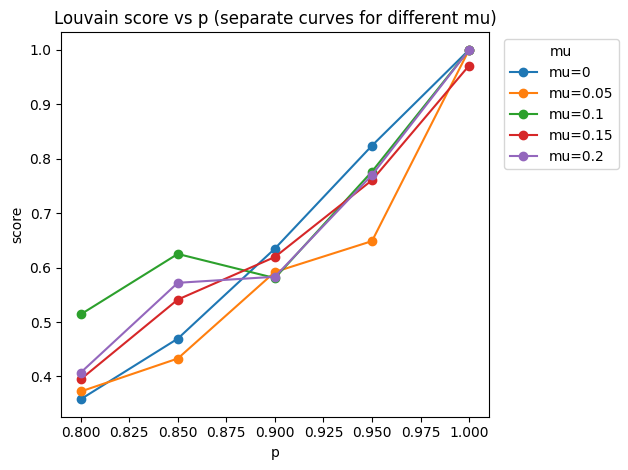

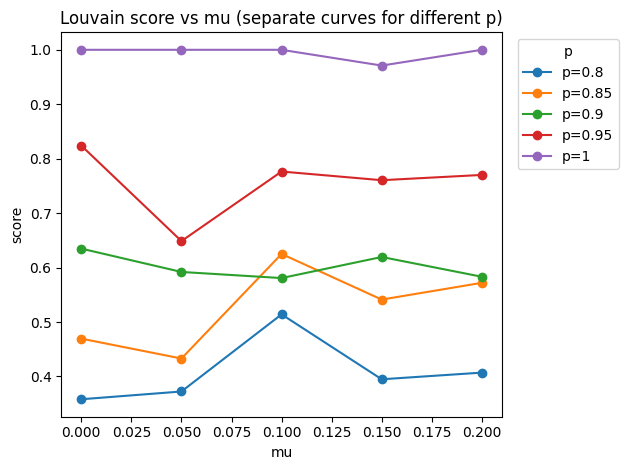

In [65]:
import pandas as pd
import matplotlib.pyplot as plt


tmp = df_louvain[df_louvain["status"] == "ok"].copy()


tmp["p"] = pd.to_numeric(tmp["p"], errors="coerce")
tmp["mu"] = pd.to_numeric(tmp["mu"], errors="coerce")
tmp["score"] = pd.to_numeric(tmp["score"], errors="coerce")
tmp = tmp.dropna(subset=["p", "mu", "score"])


tmp = tmp.groupby(["p", "mu"], as_index=False)["score"].mean()


plt.figure()
for mu, sub in tmp.groupby("mu", sort=True):
    sub = sub.sort_values("p")
    plt.plot(sub["p"], sub["score"], marker="o", label=f"mu={mu:g}")

plt.xlabel("p")
plt.ylabel("score")
plt.title("Louvain score vs p (separate curves for different mu)")
plt.legend(title="mu", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure()
for p, sub in tmp.groupby("p", sort=True):
    sub = sub.sort_values("mu")
    plt.plot(sub["mu"], sub["score"], marker="o", label=f"p={p:g}")

plt.xlabel("mu")
plt.ylabel("score")
plt.title("Louvain score vs mu (separate curves for different p)")
plt.legend(title="p", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
louvain_pred = build_partition_from_csv("result/louvain_syn_net_test.csv")
louvain_score = dynamic_mi(gt, louvain_pred, normalisation="ami")
print("Louvain Dynamic AMI =", louvain_score)